In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [44]:
# Reading Data

In [45]:
df = pd.read_csv('customer_churn.csv')

In [46]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [48]:
#Exploratory Data Analysis & Feature Engineering

In [49]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [50]:
(df['TotalCharges'] == " ").sum()

11

In [51]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [52]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [53]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [54]:
df['TotalCharges'].fillna(0 , inplace = True)

C:\Users\Arpita\AppData\Local\Temp\ipykernel_22672\828537808.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0 , inplace = True)


In [55]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [56]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

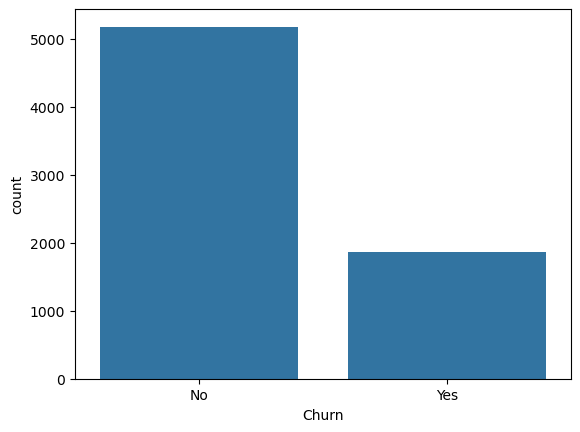

In [57]:
sns.countplot(x = "Churn" , data = df)
plt.show()

In [58]:
#Observation - Imbalanced Dataset

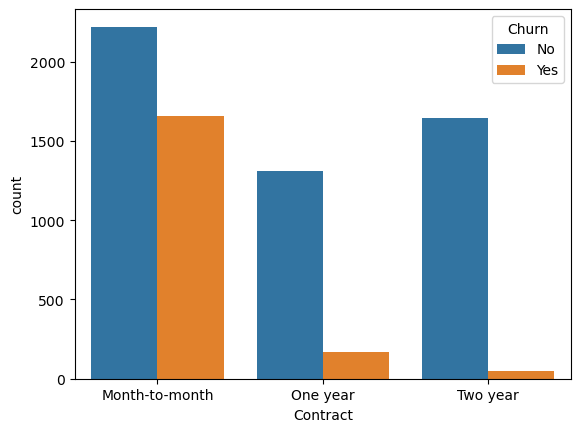

In [59]:
sns.countplot(x = "Contract" , hue = "Churn" , data = df)
plt.show()

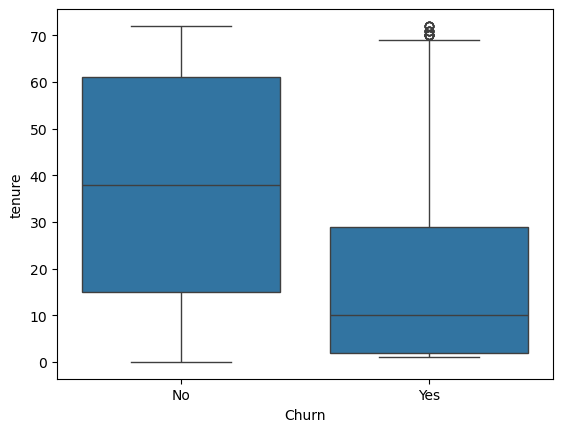

In [60]:
sns.boxplot(x = "Churn" , y = "tenure" , data = df)
plt.show()

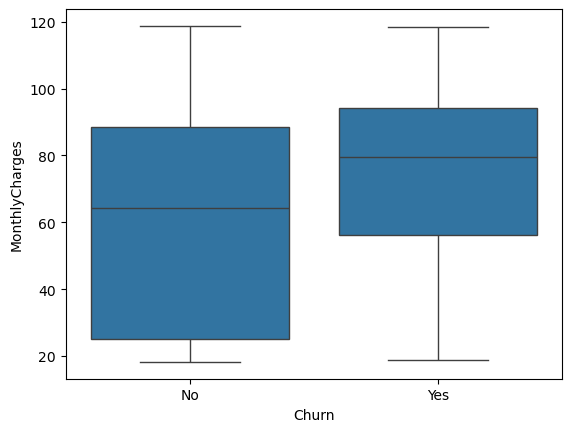

In [61]:
sns.boxplot(x = "Churn" , y = "MonthlyCharges" , data = df)
plt.show()

In [62]:
df.drop("customerID" , axis = 1 , inplace = True)

In [63]:
df["Churn"] = df["Churn"].map({'Yes' : 1 , 'No'  : 0})

In [64]:
def tenure_group(x):
    if x <= 12:
        return "0-1 year"
    elif x <= 24:
        return "1-2 year"
    elif x <= 48:
        return "2-4 year"
    else:
        return "4+ years"


df["tenure_group"] = df["tenure"].apply(tenure_group)

In [65]:
df = pd.get_dummies(df , drop_first = True)

In [66]:
df.shape

(7043, 34)

In [67]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2 year,tenure_group_2-4 year,tenure_group_4+ years
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,True,False,True,False,False,False,False


In [68]:
# Splitting the data into train & test data

In [69]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn" , axis = 1)
y = df["Churn"]

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42)

In [70]:
# Training Different Models

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [72]:
log_reg = LogisticRegression(max_iter = 1000)
random_for = RandomForestClassifier()
knn = KNeighborsClassifier()

In [73]:
knn.fit(X_train , y_train)

KNeighborsClassifier()

In [74]:
random_for.fit(X_train , y_train)

RandomForestClassifier()

In [75]:
log_reg.fit(X_train , y_train)

C:\Users\Arpita\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
# Evaluating the models

In [76]:
from sklearn.metrics import classification_report
print("Logistic Regression")
pred = log_reg.predict(X_test)
print(classification_report(pred , y_test))

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      1102
           1       0.57      0.69      0.62       307

    accuracy                           0.82      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.83      0.82      0.82      1409



In [77]:
print("Random Forest Classifier")
pred = random_for.predict(X_test)
print(classification_report(pred , y_test))

Random Forest Classifier
              precision    recall  f1-score   support

           0       0.91      0.83      0.87      1146
           1       0.46      0.66      0.54       263

    accuracy                           0.79      1409
   macro avg       0.69      0.74      0.71      1409
weighted avg       0.83      0.79      0.81      1409



In [78]:
print("K Neighbors Classifier")
pred = knn.predict(X_test)
print(classification_report(pred , y_test))

K Neighbors Classifier
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1108
           1       0.49      0.60      0.54       301

    accuracy                           0.78      1409
   macro avg       0.68      0.71      0.70      1409
weighted avg       0.80      0.78      0.79      1409



In [79]:
#Observation - Logistic Regression is working best so we will work on improving that as of now

In [80]:
from sklearn.model_selection import GridSearchCV


In [81]:
params = {
    "C" : [0.01 , 0.1 , 1 , 10 , 100],
    "penalty" : ["l2"],
    "solver" : ["lbfgs"]}

In [82]:
grid = GridSearchCV(log_reg , param_grid = params , cv = 5 , scoring = "recall")
grid.fit(X_train , y_train)

C:\Users\Arpita\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Arpita\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             scoring='recall')

In [83]:
best_params = grid.best_params_

In [84]:
best_params

{'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}

In [85]:
pred = grid.predict(X_test)
print(classification_report(y_test , pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.56      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.73      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [86]:
# Trying to improve Random Forest

In [87]:
params  = {
    "n_estimators" : [100,200],
    "max_depth" : [5,10,None],
    "min_samples_split" : [2,5],
}

In [88]:
grid_rf = GridSearchCV(RandomForestClassifier() , param_grid = params , cv = 3 ,scoring = "recall")

In [89]:
grid_rf.fit(X_train , y_train)
pred = grid_rf.predict(X_test)

In [90]:
best_params = grid_rf.best_params_

In [91]:
best_params


{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

In [92]:
print(classification_report(y_test , pred))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.69      0.51      0.59       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [93]:
# Finding the important features

In [94]:
feature_importance = pd.Series(
    random_for.feature_importances_ , index = X.columns).sort_values(ascending = False)
feature_importance.head(10)

TotalCharges                      0.185980
MonthlyCharges                    0.167460
tenure                            0.156441
InternetService_Fiber optic       0.037670
PaymentMethod_Electronic check    0.034845
gender_Male                       0.028431
Contract_Two year                 0.026810
PaperlessBilling_Yes              0.026052
OnlineSecurity_Yes                0.024887
Partner_Yes                       0.024468
dtype: float64

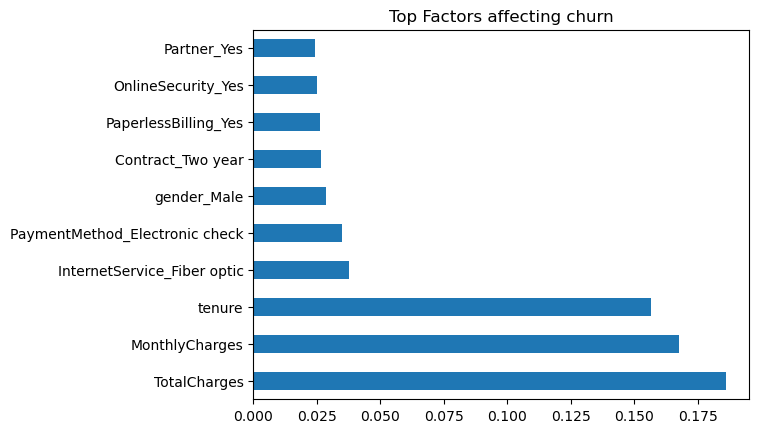

In [95]:
feature_importance.head(10).plot(kind = "barh")
plt.title("Top Factors affecting churn")
plt.show()

In [96]:
##OBSERVATION
#This shows that factors like TotalCharges , MonthlyCharges and tenure affect the most in customer churn.
#Customers with higher monthly charges and small tenure are more likely to churn , indicating that early customer experience play a crucial role in retention.

In [97]:
import pickle
pickle.dump(log_reg, open("model.pkl", "wb"))

In [98]:
import pickle

pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))